In [2]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import numpy as np
import arc
import pairinteraction as pi
if pi.Database.get_global_database() is None:
    pi.Database.initialize_global_database(download_missing=True)
import os
from IPython.display import Latex
import scipy
import pandas as pd
from pandas import DataFrame

import sys
sys.path.append(os.path.abspath("C:\\Users\\Tommy\\OneDrive - Durham University\\level 4 Project\\Code Directory\\L4-code-directory-2"))
from my_functions import *
h = scipy.constants.h
epsilon_0 = scipy.constants.epsilon_0
a_0 = scipy.constants.physical_constants['Bohr radius']
e = scipy.constants.e


In [3]:
from pairinteraction.visualization.colormaps import alphamagma
import os
colours = ('orange', 'green', 'red', 'blue')
orbs = ('s', 'p', 'd', 'f')

atom1 = 'Rb'
atom2 ='Cs'
l1_0, l2_0 = 2, 2
l1_1, l2_1 = 1, 3
j1_0, j2_0 = 3/2, 5/2



if atom1 == 'Rb87':
    arc_atom1 = arc.Rubidium()
elif atom1 == 'Cs':
    arc_atom1 = arc.Caesium()
if atom2 == 'Rb87':
    arc_atom2 = arc.Rubidium()
elif atom2 == 'Cs':
    arc_atom2 = arc.Caesium()  

energy_unit = 'MHz'
    

In [4]:
channels = channels_import(atom1, l1_0, j1_0, atom2, l2_0, j2_0, l1_1, l2_1)

   Unnamed: 0  n1_0  l1_0  j1_0  n2_0  l2_0  j2_0  n1_1  l1_1  j1_1  ...  \
0           3    45     2   1.5    51     2   2.5    46     1   0.5  ...   
1           2    45     2   1.5    51     2   2.5    46     1   0.5  ...   
2           6    47     2   1.5    54     2   2.5    48     1   1.5  ...   
3           4    53     2   1.5    60     2   2.5    54     1   0.5  ...   
4           5    53     2   1.5    60     2   2.5    54     1   0.5  ...   
5           8    54     2   1.5    62     2   2.5    55     1   1.5  ...   
6           0    59     2   1.5    57     2   2.5    61     1   0.5  ...   
7           1    59     2   1.5    57     2   2.5    61     1   0.5  ...   
8           7    61     2   1.5    69     2   2.5    62     1   0.5  ...   

   asymmetry 4um  energy 4um  asymmetry 3um  energy 3um  energy_Rb 3um  \
0    -583.190951  -34.489343     -28.409727  -93.572437     -11.269094   
1    -472.400891  -34.617153     -47.273165  -94.268968      -4.130529   
2     -89.981441 

In [5]:
channel = 3
c = channels.loc[channel]
# set atom properties
n1_0, l1_0, j1_0 = int(c['n1_0']), int(c['l1_0']), c['j1_0']
n2_0, l2_0, j2_0 = int(c['n2_0']), int(c['l2_0']), c['j2_0'] 
mj1_0s, mj2_0s = np.arange(-j1_0, j1_0+1), np.arange(-j2_0, j2_0+1)
f1_0, f2_0 = 1, 1

n1_1, l1_1, j1_1 = int(c['n1_1']), int(c['l1_1']), c['j1_1']
n2_1, l2_1, j2_1 =  int(c['n2_1']), int(c['l2_1']), c['j2_1']
f1_1, f2_1 = 1, 1

btunes = np.unique(magTune_import(atom1, n1_0, l1_0, j1_0, atom2, n2_0, l2_0, j2_0, l1_1, l2_1))

ket1 = pi.KetAtom(atom1, n=n1_0, l=l1_0, m=j1_0, j=j1_0)
ket2 = pi.KetAtom(atom2, n=n2_0, l=l2_0, m=j2_0, j=j2_0)
ket1_1 = pi.KetAtom(atom1, n=n1_1, l=l1_1, j=j1_1, m=j1_1)
ket2_1 = pi.KetAtom(atom2, n=n2_1, l=l2_1, j=j2_1, m=j2_1)
ket1_energy = ket1.get_energy(unit=energy_unit)
ket2_energy = ket2.get_energy(unit=energy_unit)

defect = c['defect']


bs = np.array([0])
bs = np.append(bs, np.array(btunes))

print(mj1_0s, mj2_0s)


Magnetic file doesn't exist
[-1.5 -0.5  0.5  1.5] [-2.5 -1.5 -0.5  0.5  1.5  2.5]


0     -2427.463575
1      2972.769640
2     -1257.549177
3     -3538.581156
4     -1822.636098
          ...     
603      -0.100635
604       0.086659
605     111.053406
606      -0.099231
607       0.085256
Name: energy, Length: 608, dtype: float64
[-4142.567546844482, -3495.0198149681096, 3624.0905389785767, 1284.2311379909515, -2268.354068994522, -1703.400452375412, -2584.4688072204585, 2348.6450147628784, -1537.8859047889712, -2071.450912475586, 953.7178132534028, -1326.0341839790344, 1640.701379776001, -927.9222395420074, 741.5702977180481, 1230.8494143486023, -1051.5015664100647, 992.2474513053894, 588.624190568924, -751.4354610443115, 857.8520007133486, 469.752268075943, -558.9314949512482, -407.6454441547394, -430.8644099235535, 376.3670446872711, 303.82888865470886, -328.619256734848, 247.7792510986328, -263.3965358734131, 204.38147401809687, -213.73225498199463, 170.6550211906433, -175.73102641105652, 144.58118343353271, -146.22486543655396, 105.44406509399414, 125.765898942

TypeError: 'int' object is not callable

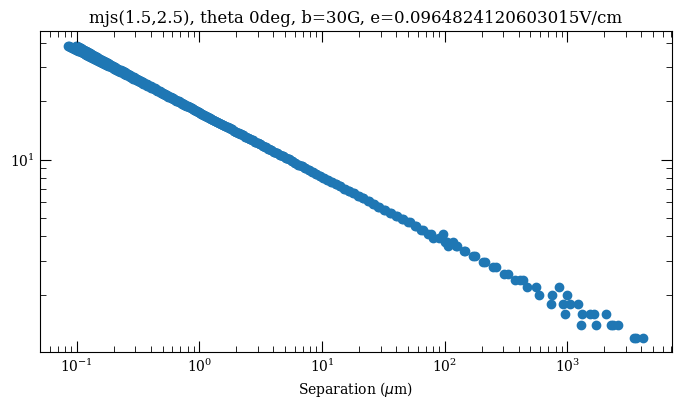

In [47]:
# both plotted together log scale
import os

datapath_field = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Data\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\separations\\inter intra\\field-corrected\\'

# ax.set_ylim(-0.01, 0.01)
theta=0
prop_cycle = plt.rcParams['axes.prop_cycle']
colours = prop_cycle.by_key()['color']
# theta=0
# system_atom = system_atom_dict[efield]
b=30
theta = 0
mj1 = 3/2
mj2 = 5/2
elec=0.0964824120603015

# print(overlapped_inter)
min_overlap = .1
corrected_inter = pd.read_csv(datapath_field + f'inter\\mjs ({mj1}, {mj2}), theta {theta}, b {np.round(b,4)}G, e{elec}Vcm.csv')
print(corrected_inter['energy'])
fig, ax = plt.subplots(1, 1, figsize=(7, 4))

ax.set_xlabel(r"Separation ($\mu$m)")
plt.tight_layout()
ax.set_title(fr'mjs({mj1},{mj2}), theta {theta}deg, b={np.round(b,2)}G, e={elec}V/cm')
energy_lim = abs(20)
offset=defect/2
min_energy = -energy_lim+offset
max_energy = energy_lim+offset
rs, energy, overlap = [], [], []
min_overlap = 0.08

for e, o, r in zip(corrected_inter['energy'], corrected_inter['overlap'], corrected_inter['r']):
    
    if o >= min_overlap:
        rs.append(r)
        energy.append(e)
        overlap.append(o)
print(energy)
# scat = plt.scatter(
#     rs,
#     abs(np.array(energy)),
#     vmin=0,
#     vmax=1,
#     marker='.',
# )
ax.set_yscale('log')
ax.set_xscale('log')

inds = np.argwhere(abs(np.array(energy)) > 2)
r_range = np.array(rs)[inds]
energy_two = np.array(energy)[inds]
# print(energy_two)
# plt.scatter(r_range, abs(energy_two))
plt.scatter(abs(np.array(energy)), rs)
print(max(r_range))
plt.show()

plt.close()


[ 7.46733668  7.46733668  7.66331658  7.66331658  7.85929648  7.85929648
  8.05527638  8.05527638  8.25125628  8.25125628  8.44723618  8.44723618
  8.64321608  8.64321608  8.83919598  8.83919598  9.03517588  9.03517588
  9.23115578  9.23115578  9.42713568  9.42713568  9.62311558  9.62311558
  9.81909548  9.81909548 10.01507538 10.01507538 10.21105528 10.21105528
 10.40703518 10.40703518 10.60301508 10.60301508 10.79899497 10.79899497
 10.99497487 10.99497487 11.19095477 11.19095477 11.38693467 11.38693467
 11.58291457 11.58291457 11.77889447 11.77889447 11.97487437 11.97487437
 12.17085427 12.17085427 12.36683417 12.36683417 12.56281407 12.56281407
 12.75879397 12.75879397 12.95477387 12.95477387 13.15075377 13.15075377
 13.34673367 13.34673367 13.54271357 13.54271357 13.73869347 13.73869347
 13.93467337 13.93467337 14.13065327 14.13065327 14.32663317 14.32663317
 14.52261307 14.52261307 14.71859296 14.71859296 14.91457286 14.91457286
 15.11055276 15.11055276 15.30653266 15.30653266 15

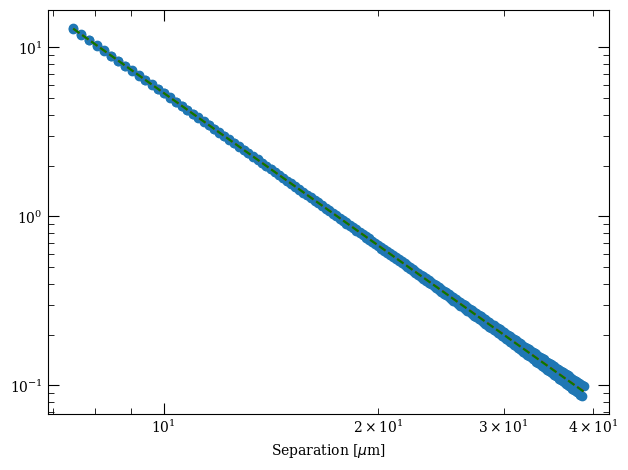

c_3 = 5.382228338330462 $\pm$ 0.001150600472243506 GHz $\mu m$
402 402


In [48]:
fitted_datapath =fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Data\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\separations\\inter intra\\field-corrected\\fitted\\'
if not os.path.exists(fitted_datapath):
    os.makedirs(fitted_datapath)

min =80
max = -1
# print(max(rs))
energies = abs(np.array(energy)[min:max])
r=np.array(rs[min:max])
print(r)
# print(rs)
# print(np.shape(d))
def func(x, c):
    return c/(x)**3
def vdw_func(x, rvdw, A, B):
    return A + B * (1-np.sqrt(1+(rvdw/x)**6))/(1-np.sqrt(1+rvdw**6))
fig, ax = plt.subplots()  

popt, pcov = scipy.optimize.curve_fit(vdw_func, r, energies)
ax.plot(r, vdw_func(r, *popt), linestyle='dashed', color='red')

popt, pcov = scipy.optimize.curve_fit(func, r, energies)
ax.plot(r, func(r, *popt), linestyle='dashed', color='green')

ax.scatter(r, energies)
ax.set_yscale('log')
ax.set_xscale('log')

# ax.hlines((-energy_dif, energy_dif, min_defect), xmin=r[0], xmax=r[-1], linestyle='dashed', alpha = 0.7)
ax.set_xlabel(r"Separation [$\mu$m]")
# ax.axvline((popt[0]))
# ax.set_xlim((0,25))
# fig.colorbar(scat, ax=ax, label=fr"Overlap with |{ket1.n}${orbs[int(ket1.l)]}_{{{ket1.j}}}$, $m_j$={ket1.m}, {ket2.n}${orbs[int(ket2.l)]}_{{{ket2.j}}}$, $m_j$={ket2.m}$\rangle$", cmap = 'plasma')
fig.tight_layout()
plt.show()
print(fr'c_3 = {popt[0]/1e3} $\pm$ {np.sqrt(np.diag(pcov))[0]/1e3} GHz $\mu m$')
ens = func(np.array(rs), *popt)
print(len(ens), len(rs))
fitted_inter = {'energy' : ens, 'rs' : rs}
pd.DataFrame(fitted_inter).to_csv(fitted_datapath + f'mjs ({mj1}, {mj2}), theta {theta}, b {b}G, e{elec}Vcm.csv')
# fig.savefig(path + 'fitted level')

In [49]:
fitted = pd.read_csv(fitted_datapath + f'mjs ({mj1}, {mj2}), theta {theta}, b {b}G, e{elec}Vcm.csv')
print(fitted_datapath + f'mjs ({mj1}, {mj2}), theta {theta}, b {b}G, e{elec}Vcm.csv')

C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Data\\interesting channels\\RbCs\\53d1.5 60d2.5\\separations\\inter intra\\field-corrected\\fitted\\mjs (1.5, 2.5), theta 0, b 30G, e0.0964824120603015Vcm.csv
